<a href="https://colab.research.google.com/github/sarankumar44/EDGEKWS/blob/main/EdgeKWS_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import librosa
import sklearn

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Librosa:", librosa.__version__)
print("Everything is ready!")

TensorFlow: 2.20.0
NumPy: 2.1.3
Librosa: 0.11.0
Everything is ready!


In [1]:
import os

folders = [
    "dataset/hey_edge",
    "dataset/unknown",
    "dataset/silence",
    "models",
    "evaluation"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created!")

Project folders created!


In [2]:
import os

folder = "dataset/hey_edge"

print("Files found:")

for file in os.listdir(folder):
    print(file)

Files found:
Record (online-voice-recorder.com).mp3
Record (online-voice-recorder.com) (3).mp3
Record (online-voice-recorder.com) (1).mp3
Record (online-voice-recorder.com) (2).mp3
Record (online-voice-recorder.com) (4).mp3


In [3]:
import os

old_folder = "dataset/hey_edge"
new_folder = "dataset/dear_folk"

os.rename(old_folder, new_folder)

print("Folder renamed successfully!")

Folder renamed successfully!


In [4]:
import os

folder = "dataset/dear_folk"

print("Files found:")

for file in os.listdir(folder):
    print(file)

Files found:
Record (online-voice-recorder.com).mp3
Record (online-voice-recorder.com) (3).mp3
Record (online-voice-recorder.com) (1).mp3
Record (online-voice-recorder.com) (2).mp3
Record (online-voice-recorder.com) (4).mp3


In [5]:
import os
import librosa
import soundfile as sf

input_folder = "dataset/dear_folk"
output_folder = "dataset/dear_folk_wav"

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):

    if filename.lower().endswith(".mp3"):

        input_path = os.path.join(input_folder, filename)

        # Load MP3 and convert to 16 kHz mono
        audio, sr = librosa.load(
            input_path,
            sr=16000,
            mono=True
        )

        # Create WAV filename
        output_name = os.path.splitext(filename)[0] + ".wav"
        output_path = os.path.join(output_folder, output_name)

        # Save WAV
        sf.write(output_path, audio, 16000)

        print("Converted:", filename)

print("\n✅ Conversion completed!")

Converted: Record (online-voice-recorder.com).mp3
Converted: Record (online-voice-recorder.com) (3).mp3
Converted: Record (online-voice-recorder.com) (1).mp3
Converted: Record (online-voice-recorder.com) (2).mp3
Converted: Record (online-voice-recorder.com) (4).mp3

✅ Conversion completed!


In [6]:
import os
import librosa

folder = "dataset/dear_folk_wav"

for filename in os.listdir(folder):

    if filename.endswith(".wav"):

        path = os.path.join(folder, filename)

        audio, sr = librosa.load(
            path,
            sr=None,
            mono=True
        )

        duration = len(audio) / sr

        print(
            filename,
            "| Sample rate:", sr,
            "| Duration:", round(duration, 2), "seconds"
        )

Record (online-voice-recorder.com) (2).wav | Sample rate: 16000 | Duration: 1.42 seconds
Record (online-voice-recorder.com) (3).wav | Sample rate: 16000 | Duration: 0.72 seconds
Record (online-voice-recorder.com).wav | Sample rate: 16000 | Duration: 0.94 seconds
Record (online-voice-recorder.com) (1).wav | Sample rate: 16000 | Duration: 0.82 seconds
Record (online-voice-recorder.com) (4).wav | Sample rate: 16000 | Duration: 1.22 seconds


In [7]:
import os
import librosa
import soundfile as sf
import numpy as np

input_folder = "dataset/dear_folk_wav"
output_folder = "dataset/dear_folk_1sec"

os.makedirs(output_folder, exist_ok=True)

TARGET_LENGTH = 16000  # 1 second at 16 kHz

for filename in os.listdir(input_folder):

    if filename.endswith(".wav"):

        input_path = os.path.join(input_folder, filename)

        # Load audio
        audio, sr = librosa.load(
            input_path,
            sr=16000,
            mono=True
        )

        # Make exactly 16000 samples
        if len(audio) > TARGET_LENGTH:
            # Cut to 1 second
            audio = audio[:TARGET_LENGTH]

        elif len(audio) < TARGET_LENGTH:
            # Pad with zeros
            padding = TARGET_LENGTH - len(audio)
            audio = np.pad(audio, (0, padding))

        # Save
        output_path = os.path.join(output_folder, filename)

        sf.write(
            output_path,
            audio,
            16000
        )

        print(
            filename,
            "→",
            len(audio),
            "samples"
        )

print("\n✅ All recordings are now exactly 1 second!")

Record (online-voice-recorder.com) (2).wav → 16000 samples
Record (online-voice-recorder.com) (3).wav → 16000 samples
Record (online-voice-recorder.com).wav → 16000 samples
Record (online-voice-recorder.com) (1).wav → 16000 samples
Record (online-voice-recorder.com) (4).wav → 16000 samples

✅ All recordings are now exactly 1 second!


In [8]:
import os
import librosa

folder = "dataset/dear_folk_1sec"

for filename in os.listdir(folder):

    if filename.endswith(".wav"):

        audio, sr = librosa.load(
            os.path.join(folder, filename),
            sr=None,
            mono=True
        )

        print(
            filename,
            "| Sample rate:", sr,
            "| Samples:", len(audio),
            "| Duration:", len(audio) / sr
        )

Record (online-voice-recorder.com) (2).wav | Sample rate: 16000 | Samples: 16000 | Duration: 1.0
Record (online-voice-recorder.com) (3).wav | Sample rate: 16000 | Samples: 16000 | Duration: 1.0
Record (online-voice-recorder.com).wav | Sample rate: 16000 | Samples: 16000 | Duration: 1.0
Record (online-voice-recorder.com) (1).wav | Sample rate: 16000 | Samples: 16000 | Duration: 1.0
Record (online-voice-recorder.com) (4).wav | Sample rate: 16000 | Samples: 16000 | Duration: 1.0


Audio samples: 16000
MFCC shape: (13, 32)


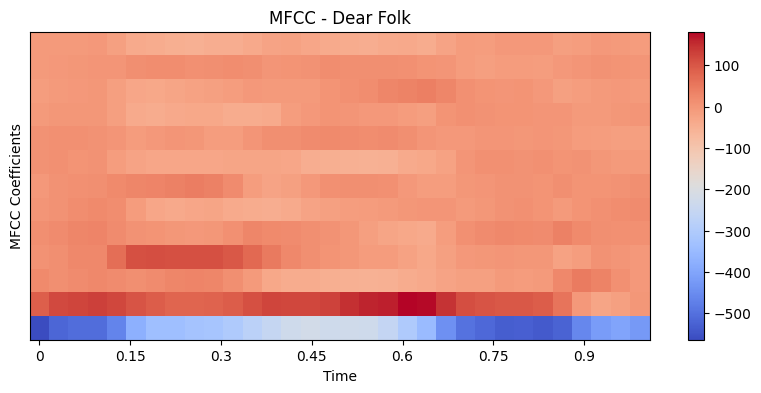

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Select one audio file
folder = "dataset/dear_folk_1sec"
filename = os.listdir(folder)[0]
filepath = os.path.join(folder, filename)

# Load audio
audio, sr = librosa.load(
    filepath,
    sr=16000,
    mono=True
)

# Generate MFCC
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("Audio samples:", len(audio))
print("MFCC shape:", mfcc.shape)

# Display MFCC
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC - Dear Folk")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time")
plt.show()

In [11]:
import os
import librosa
import numpy as np

input_folder = "dataset/dear_folk_1sec"

X = []

for filename in os.listdir(input_folder):

    if filename.endswith(".wav"):

        filepath = os.path.join(input_folder, filename)

        # Load audio
        audio, sr = librosa.load(
            filepath,
            sr=16000,
            mono=True
        )

        # Generate MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        )

        # Add channel dimension for CNN
        mfcc = mfcc[..., np.newaxis]

        X.append(mfcc)

# Convert list to NumPy array
X = np.array(X)

print("MFCC dataset shape:", X.shape)

MFCC dataset shape: (5, 13, 32, 1)


In [12]:
import tensorflow as tf

dataset_url = "http://download.tensorflow.org/data/mini_speech_commands.zip"

path = tf.keras.utils.get_file(
    "mini_speech_commands.zip",
    origin=dataset_url,
    extract=True
)

print("Dataset downloaded!")
print(path)

182082353/182082353 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset downloaded!
/root/.keras/datasets/mini_speech_commands_extracted


In [15]:
import os
import shutil
import random

# Find the downloaded dataset
base_path = os.path.dirname(path)

# The extracted folder
speech_folder = os.path.join(base_path, "mini_speech_commands")

# Words available in the public dataset
words = [
    "down",
    "go",
    "left",
    "no",
    "right",
    "stop",
    "up",
    "yes"
]

output_folder = "dataset/unknown"
os.makedirs(output_folder, exist_ok=True)

# Number of samples from each word
samples_per_word = 20

random.seed(42)

count = 0

for word in words:

    word_folder = os.path.join(speech_folder, word)

    files = [
        f for f in os.listdir(word_folder)
        if f.endswith(".wav")
    ]

    random.shuffle(files)

    selected = files[:samples_per_word]

    for i, filename in enumerate(selected):

        source = os.path.join(word_folder, filename)

        new_name = f"{word}_{i}.wav"
        destination = os.path.join(output_folder, new_name)

        shutil.copy(source, destination)

        count += 1

print("Unknown samples created:", count)

FileNotFoundError: [Errno 2] No such file or directory: '/root/.keras/datasets/mini_speech_commands/down'

In [16]:
import os

print("Keras dataset folders:")

keras_folder = "/root/.keras/datasets"

for item in os.listdir(keras_folder):
    print(item)

Keras dataset folders:
mini_speech_commands.zip
mini_speech_commands_extracted


In [17]:
import os

for root, dirs, files in os.walk("/root/.keras/datasets"):
    if "down" in dirs:
        print("FOUND DATASET:")
        print(os.path.join(root, "down"))

FOUND DATASET:
/root/.keras/datasets/mini_speech_commands_extracted/mini_speech_commands/down
FOUND DATASET:
/root/.keras/datasets/mini_speech_commands_extracted/__MACOSX/mini_speech_commands/down


In [18]:
import os
import shutil
import random

# Correct public dataset path
speech_folder = "/root/.keras/datasets/mini_speech_commands_extracted/mini_speech_commands"

# Our EdgeKWS unknown folder
output_folder = "dataset/unknown"
os.makedirs(output_folder, exist_ok=True)

# Public words we will treat as "unknown"
words = [
    "down",
    "go",
    "left",
    "no",
    "right",
    "stop",
    "up",
    "yes"
]

# Take 20 recordings from each word for now
samples_per_word = 20

random.seed(42)

count = 0

for word in words:

    word_folder = os.path.join(speech_folder, word)

    files = [
        f for f in os.listdir(word_folder)
        if f.lower().endswith(".wav")
    ]

    random.shuffle(files)

    selected = files[:samples_per_word]

    for i, filename in enumerate(selected):

        source = os.path.join(word_folder, filename)

        new_name = f"{word}_{i}.wav"
        destination = os.path.join(output_folder, new_name)

        shutil.copy(source, destination)

        count += 1

    print(word, "→", len(selected), "files")

print("\n✅ Unknown samples created:", count)

down → 20 files
go → 20 files
left → 20 files
no → 20 files
right → 20 files
stop → 20 files
up → 20 files
yes → 20 files

✅ Unknown samples created: 160


In [19]:
import os
import shutil
import random

# Public dataset base path
speech_folder = "/root/.keras/datasets/mini_speech_commands_extracted/mini_speech_commands"

# Create silence folder
output_folder = "dataset/silence"
os.makedirs(output_folder, exist_ok=True)

# Collect audio from the public speech dataset
all_audio = []

for word in os.listdir(speech_folder):

    word_folder = os.path.join(speech_folder, word)

    if os.path.isdir(word_folder):

        for filename in os.listdir(word_folder):

            if filename.lower().endswith(".wav"):
                all_audio.append(
                    os.path.join(word_folder, filename)
                )

# Select 160 files
random.seed(123)
random.shuffle(all_audio)

selected = all_audio[:160]

for i, source in enumerate(selected):

    destination = os.path.join(
        output_folder,
        f"background_{i}.wav"
    )

    shutil.copy(source, destination)

print("Silence/background samples created:", len(selected))

Silence/background samples created: 160


In [20]:
import os
import librosa
import soundfile as sf
import numpy as np

TARGET_SR = 16000
TARGET_LENGTH = 16000

folders = [
    "dataset/unknown",
    "dataset/silence"
]

for input_folder in folders:

    output_folder = input_folder + "_1sec"
    os.makedirs(output_folder, exist_ok=True)

    print("\nProcessing:", input_folder)

    for filename in os.listdir(input_folder):

        if filename.lower().endswith(".wav"):

            input_path = os.path.join(input_folder, filename)

            # Load and convert to 16 kHz mono
            audio, sr = librosa.load(
                input_path,
                sr=TARGET_SR,
                mono=True
            )

            # Make exactly 1 second
            if len(audio) > TARGET_LENGTH:
                audio = audio[:TARGET_LENGTH]

            elif len(audio) < TARGET_LENGTH:
                padding = TARGET_LENGTH - len(audio)
                audio = np.pad(audio, (0, padding))

            # Save
            output_path = os.path.join(
                output_folder,
                filename
            )

            sf.write(
                output_path,
                audio,
                TARGET_SR
            )

    print("Completed:", output_folder)

print("\n✅ Unknown and silence audio standardized!")


Processing: dataset/unknown
Completed: dataset/unknown_1sec

Processing: dataset/silence
Completed: dataset/silence_1sec

✅ Unknown and silence audio standardized!


In [21]:
import os
import librosa

folders = [
    "dataset/unknown_1sec",
    "dataset/silence_1sec"
]

for folder in folders:

    files = [
        f for f in os.listdir(folder)
        if f.endswith(".wav")
    ]

    print("\n", folder)
    print("Number of files:", len(files))

    # Check first 3 files
    for filename in files[:3]:

        audio, sr = librosa.load(
            os.path.join(folder, filename),
            sr=None,
            mono=True
        )

        print(
            filename,
            "| SR:", sr,
            "| Samples:", len(audio),
            "| Duration:", len(audio) / sr
        )


 dataset/unknown_1sec
Number of files: 160
up_1.wav | SR: 16000 | Samples: 16000 | Duration: 1.0
right_14.wav | SR: 16000 | Samples: 16000 | Duration: 1.0
stop_5.wav | SR: 16000 | Samples: 16000 | Duration: 1.0

 dataset/silence_1sec
Number of files: 160
background_59.wav | SR: 16000 | Samples: 16000 | Duration: 1.0
background_156.wav | SR: 16000 | Samples: 16000 | Duration: 1.0
background_157.wav | SR: 16000 | Samples: 16000 | Duration: 1.0


In [22]:
import os
import librosa
import soundfile as sf
import numpy as np
import random

input_folder = "dataset/dear_folk_1sec"
output_folder = "dataset/dear_folk_augmented"

os.makedirs(output_folder, exist_ok=True)

TARGET_SR = 16000
TARGET_LENGTH = 16000

random.seed(42)

files = [
    f for f in os.listdir(input_folder)
    if f.endswith(".wav")
]

print("Original files:", len(files))

# Keep original recordings
for filename in files:
    source = os.path.join(input_folder, filename)
    destination = os.path.join(output_folder, filename)

    audio, sr = librosa.load(
        source,
        sr=TARGET_SR,
        mono=True
    )

    sf.write(destination, audio, TARGET_SR)

# Create augmented samples
samples_per_original = 30

count = 0

for filename in files:

    source = os.path.join(input_folder, filename)

    audio, sr = librosa.load(
        source,
        sr=TARGET_SR,
        mono=True
    )

    for i in range(samples_per_original):

        augmented = audio.copy()

        # Random volume change
        gain = random.uniform(0.7, 1.3)
        augmented = augmented * gain

        # Random time shift
        shift = random.randint(-1600, 1600)

        if shift > 0:
            augmented = np.pad(
                augmented,
                (shift, 0)
            )[:TARGET_LENGTH]

        elif shift < 0:
            augmented = np.pad(
                augmented,
                (0, abs(shift))
            )[-shift:TARGET_LENGTH-shift]

        # Make sure length is exactly 1 second
        if len(augmented) > TARGET_LENGTH:
            augmented = augmented[:TARGET_LENGTH]

        elif len(augmented) < TARGET_LENGTH:
            augmented = np.pad(
                augmented,
                (0, TARGET_LENGTH - len(augmented))
            )

        output_name = f"aug_{count}.wav"

        sf.write(
            os.path.join(output_folder, output_name),
            augmented,
            TARGET_SR
        )

        count += 1

print("Augmented samples:", count)
print("Total Dear Folk samples:",
      len(os.listdir(output_folder)))

Original files: 5
Augmented samples: 150
Total Dear Folk samples: 155


In [23]:
import os
import librosa
import numpy as np

# -----------------------------
# Configuration
# -----------------------------

SR = 16000
N_MFCC = 13

classes = {
    "dear_folk_augmented": 0,
    "unknown_1sec": 1,
    "silence_1sec": 2
}

X = []
y = []

# -----------------------------
# Generate MFCC
# -----------------------------

for folder, label in classes.items():

    folder_path = os.path.join("dataset", folder)

    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".wav")
    ]

    print(
        f"\nProcessing {folder}: {len(files)} files"
    )

    for filename in files:

        filepath = os.path.join(
            folder_path,
            filename
        )

        # Load audio
        audio, sr = librosa.load(
            filepath,
            sr=SR,
            mono=True
        )

        # Generate MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC
        )

        # Add CNN channel dimension
        mfcc = mfcc[..., np.newaxis]

        X.append(mfcc)
        y.append(label)

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n==========================")
print("MFCC DATASET CREATED")
print("==========================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass counts:")

for label in range(3):
    print(
        label,
        "→",
        np.sum(y == label)
    )


Processing dear_folk_augmented: 155 files

Processing unknown_1sec: 160 files

Processing silence_1sec: 160 files

MFCC DATASET CREATED
X shape: (475, 13, 32, 1)
y shape: (475,)

Class counts:
0 → 155
1 → 160
2 → 160


In [24]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary 20% into:
# 10% validation + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (380, 13, 32, 1) (380,)
Validation: (47, 13, 32, 1) (47,)
Testing: (48, 13, 32, 1) (48,)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Get input shape automatically
input_shape = X_train.shape[1:]

print("CNN input shape:", input_shape)

# -----------------------------
# Build Tiny CNN
# -----------------------------

model = models.Sequential([

    # Input
    layers.Input(shape=input_shape),

    # CNN Layer 1
    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Layer 2
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps to vector
    layers.Flatten(),

    # Small dense layer
    layers.Dense(
        32,
        activation="relu"
    ),

    # Output: 3 classes
    layers.Dense(
        3,
        activation="softmax"
    )
])

# -----------------------------
# Compile
# -----------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model
model.summary()

CNN input shape: (13, 32, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 16, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 16, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,507 (115.26 KB)

 Trainable params: 29,507 (115.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4895 - loss: 6.1352 - val_accuracy: 0.5745 - val_loss: 1.9228
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6316 - loss: 1.7493 - val_accuracy: 0.5745 - val_loss: 1.8097
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6921 - loss: 1.0866 - val_accuracy: 0.5745 - val_loss: 1.7831
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7579 - loss: 0.7193 - val_accuracy: 0.5745 - val_loss: 1.7309
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8053 - loss: 0.5564 - val_accuracy: 0.7021 - val_loss: 1.3632
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8184 - loss: 0.4804 - val_accuracy: 0.6596 - val_loss: 1.1534
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8711 - loss: 0.3068 - val_accuracy: 0.6596 - val_loss: 1.4405
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9158 - loss: 0.2240 - val_accuracy: 0.6809 - v

In [27]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n==========================")
print("TEST RESULTS")
print("==========================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6458 - loss: 1.3350

TEST RESULTS
Test Loss: 1.335042953491211
Test Accuracy: 0.6458333134651184
Test Accuracy (%): 64.58333134651184


In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
predictions = model.predict(X_test)

# Convert probabilities to class numbers
y_pred = np.argmax(predictions, axis=1)

# Class names
class_names = [
    "Dear Folk",
    "Unknown",
    "Silence"
]

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
              precision    recall  f1-score   support

   Dear Folk       0.94      1.00      0.97        16
     Unknown       0.47      0.50      0.48        16
     Silence       0.50      0.44      0.47        16

    accuracy                           0.65        48
   macro avg       0.64      0.65      0.64        48
weighted avg       0.64      0.65      0.64        48


Confusion Matrix:
[[16  0  0]
 [ 1  8  7]
 [ 0  9  7]]


In [29]:
model.save("models/dear_folk_cnn_baseline.keras")

print("✅ Baseline model saved!")

✅ Baseline model saved!


In [30]:
import tensorflow as tf

noise_url = "https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"

In [31]:
import os
import librosa
import soundfile as sf

input_folder = "dataset/background_raw"
output_folder = "dataset/background_1sec"

os.makedirs(output_folder, exist_ok=True)

TARGET_SR = 16000
CLIP_LENGTH = 16000  # 1 second

count = 0

for filename in os.listdir(input_folder):

    if filename.lower().endswith((".mp3", ".wav", ".m4a")):

        input_path = os.path.join(input_folder, filename)

        # Load as 16 kHz mono
        audio, sr = librosa.load(
            input_path,
            sr=TARGET_SR,
            mono=True
        )

        # Split into 1-second clips
        number_of_clips = len(audio) // CLIP_LENGTH

        for i in range(number_of_clips):

            start = i * CLIP_LENGTH
            end = start + CLIP_LENGTH

            clip = audio[start:end]

            output_name = f"background_{count}.wav"

            output_path = os.path.join(
                output_folder,
                output_name
            )

            sf.write(
                output_path,
                clip,
                TARGET_SR
            )

            count += 1

print("✅ Background processing completed!")
print("Total 1-second background samples:", count)

✅ Background processing completed!
Total 1-second background samples: 19


In [32]:
import os
import librosa
import soundfile as sf
import numpy as np
import random

input_folder = "dataset/background_1sec"
output_folder = "dataset/background_augmented"

os.makedirs(output_folder, exist_ok=True)

TARGET_LENGTH = 16000
TARGET_SR = 16000

files = [
    f for f in os.listdir(input_folder)
    if f.endswith(".wav")
]

print("Original background samples:", len(files))

# Copy originals
for filename in files:

    audio, sr = librosa.load(
        os.path.join(input_folder, filename),
        sr=TARGET_SR,
        mono=True
    )

    sf.write(
        os.path.join(output_folder, filename),
        audio,
        TARGET_SR
    )

# Create augmented versions
random.seed(42)

count = 0

for filename in files:

    audio, sr = librosa.load(
        os.path.join(input_folder, filename),
        sr=TARGET_SR,
        mono=True
    )

    for i in range(8):

        augmented = audio.copy()

        # Small volume variation
        gain = random.uniform(0.7, 1.3)
        augmented = augmented * gain

        # Small time shift
        shift = random.randint(-800, 800)

        if shift > 0:
            augmented = np.pad(
                augmented,
                (shift, 0)
            )[:TARGET_LENGTH]

        elif shift < 0:
            augmented = np.pad(
                augmented,
                (0, abs(shift))
            )[-shift:TARGET_LENGTH-shift]

        # Guarantee 1 second
        if len(augmented) > TARGET_LENGTH:
            augmented = augmented[:TARGET_LENGTH]

        elif len(augmented) < TARGET_LENGTH:
            augmented = np.pad(
                augmented,
                (0, TARGET_LENGTH - len(augmented))
            )

        output_name = f"bg_aug_{count}.wav"

        sf.write(
            os.path.join(output_folder, output_name),
            augmented,
            TARGET_SR
        )

        count += 1

print("Augmented samples:", count)
print(
    "Total background samples:",
    len(os.listdir(output_folder))
)

Original background samples: 19
Augmented samples: 152
Total background samples: 171


In [33]:
import os
import librosa
import numpy as np

SR = 16000
N_MFCC = 13

classes = {
    "dear_folk_augmented": 0,
    "unknown_1sec": 1,
    "background_augmented": 2
}

X = []
y = []

for folder, label in classes.items():

    folder_path = os.path.join("dataset", folder)

    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".wav")
    ]

    print(f"\nProcessing {folder}: {len(files)} files")

    for filename in files:

        filepath = os.path.join(folder_path, filename)

        audio, sr = librosa.load(
            filepath,
            sr=SR,
            mono=True
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC
        )

        # CNN channel dimension
        mfcc = mfcc[..., np.newaxis]

        X.append(mfcc)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n==========================")
print("IMPROVED MFCC DATASET")
print("==========================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass counts:")

for label in range(3):
    print(label, "→", np.sum(y == label))


Processing dear_folk_augmented: 155 files

Processing unknown_1sec: 160 files

Processing background_augmented: 171 files

IMPROVED MFCC DATASET
X shape: (486, 13, 32, 1)
y shape: (486,)

Class counts:
0 → 155
1 → 160
2 → 171


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (388, 13, 32, 1) (388,)
Validation: (49, 13, 32, 1) (49,)
Testing: (49, 13, 32, 1) (49,)


In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

model = models.Sequential([

    layers.Input(shape=input_shape),

    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        3,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 13, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 16, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 16, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,507 (115.26 KB)

 Trainable params: 29,507 (115.26 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4794 - loss: 7.6128 - val_accuracy: 0.7755 - val_loss: 1.6347
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8608 - loss: 0.5523 - val_accuracy: 0.9388 - val_loss: 0.0924
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9407 - loss: 0.1649 - val_accuracy: 0.9796 - val_loss: 0.0499
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9897 - loss: 0.0481 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9974 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 0.0286
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.9592 - val_loss: 0.0505
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9796 - val_loss: 0.0362
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9796 - v

In [37]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n==========================")
print("FINAL TEST RESULT")
print("==========================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9592 - loss: 0.1214

FINAL TEST RESULT
Test Loss: 0.12135286629199982
Test Accuracy: 0.9591836929321289
Test Accuracy (%): 95.91836929321289


In [38]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

class_names = [
    "Dear Folk",
    "Unknown",
    "Background"
]

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
              precision    recall  f1-score   support

   Dear Folk       1.00      1.00      1.00        16
     Unknown       1.00      0.88      0.93        16
  Background       0.89      1.00      0.94        17

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49


Confusion Matrix:
[[16  0  0]
 [ 0 14  2]
 [ 0  0 17]]


In [39]:
model.save("models/dear_folk_cnn_96percent.keras")

print("✅ Model saved")

✅ Model saved


In [40]:
model.count_params()

29507

In [41]:
import time
import numpy as np

# Take one test sample
sample = X_test[0:1]

# Warm-up inference
for _ in range(10):
    model.predict(sample, verbose=0)

# Measure inference time
times = []

for _ in range(100):
    start = time.perf_counter()

    model.predict(sample, verbose=0)

    end = time.perf_counter()

    times.append((end - start) * 1000)

times = np.array(times)

print("Inference latency results")
print("-------------------------")
print("Average:", np.mean(times), "ms")
print("Minimum:", np.min(times), "ms")
print("Maximum:", np.max(times), "ms")
print("Median :", np.median(times), "ms")

Inference latency results
-------------------------
Average: 85.53825639000934 ms
Minimum: 71.15721799982566 ms
Maximum: 268.0021520000082 ms
Median : 75.63477899975624 ms


In [42]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("models/dear_folk_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model created")
print("Size:", len(tflite_model) / 1024, "KB")

Saved artifact at '/tmp/tmp525nqcdb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138333647926864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647914384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647914576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647928592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647916880: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite model created
Size: 119.31640625 KB


In [43]:
import tensorflow as tf
import numpy as np

def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

with open("models/dear_folk_int8.tflite", "wb") as f:
    f.write(tflite_int8)

print("✅ INT8 model created!")
print("Size:", len(tflite_int8) / 1024, "KB")

Saved artifact at '/tmp/tmpeg0hlqth'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138333647926864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647914384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647918032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647914576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647928592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333647916880: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8 model created!
Size: 35.40625 KB


In [44]:
import tensorflow as tf
import numpy as np

# Load INT8 TFLite model
interpreter = tf.lite.Interpreter(
    model_path="models/dear_folk_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details)
print("Output:", output_details)

Input: [{'name': 'serving_default_keras_tensor_8:0', 'index': 0, 'shape': array([ 1, 13, 32,  1], dtype=int32), 'shape_signature': array([-1, 13, 32,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (4.379024982452393, 65), 'quantization_parameters': {'scales': array([4.379025], dtype=float32), 'zero_points': array([65], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'StatefulPartitionedCall_1:0', 'index': 22, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [45]:
correct = 0

for i in range(len(X_test)):

    sample = X_test[i:i+1].astype(np.float32)

    scale, zero_point = input_details[0]["quantization"]

    sample_int8 = np.round(
        sample / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    prediction = np.argmax(output)

    if prediction == y_test[i]:
        correct += 1

accuracy = correct / len(X_test) * 100

print("================================")
print("INT8 MODEL ACCURACY")
print("================================")
print("Correct:", correct)
print("Total:", len(X_test))
print("Accuracy:", accuracy, "%")

INT8 MODEL ACCURACY
Correct: 47
Total: 49
Accuracy: 95.91836734693877 %


In [46]:
import time
import numpy as np

# Use one test sample
sample = X_test[0:1].astype(np.float32)

scale, zero_point = input_details[0]["quantization"]

sample_int8 = np.round(
    sample / scale + zero_point
).clip(-128, 127).astype(np.int8)

# Warm-up
for _ in range(20):
    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )
    interpreter.invoke()

# Measure
times = []

for _ in range(100):

    start = time.perf_counter()

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    end = time.perf_counter()

    times.append(
        (end - start) * 1000
    )

times = np.array(times)

print("================================")
print("INT8 INFERENCE LATENCY")
print("================================")
print("Average:", np.mean(times), "ms")
print("Median :", np.median(times), "ms")
print("Minimum:", np.min(times), "ms")
print("Maximum:", np.max(times), "ms")

INT8 INFERENCE LATENCY
Average: 0.33490983006231545 ms
Median : 0.09587149952494656 ms
Minimum: 0.055050000810297206 ms
Maximum: 8.180953000191948 ms


In [47]:
import time
import librosa
import numpy as np

test_file = "dataset/dear_folk_1sec/" + os.listdir(
    "dataset/dear_folk_1sec"
)[0]

# Load audio
audio, sr = librosa.load(
    test_file,
    sr=16000,
    mono=True
)

times = []

for _ in range(100):

    start = time.perf_counter()

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=13
    )

    mfcc = mfcc[..., np.newaxis]
    mfcc = mfcc[np.newaxis, ...].astype(np.float32)

    # Quantize
    scale, zero_point = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    # CNN
    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    prediction = np.argmax(output)

    end = time.perf_counter()

    times.append(
        (end - start) * 1000
    )

times = np.array(times)

print("================================")
print("FULL PIPELINE LATENCY")
print("================================")
print("Average:", np.mean(times), "ms")
print("Median :", np.median(times), "ms")
print("Minimum:", np.min(times), "ms")
print("Maximum:", np.max(times), "ms")

FULL PIPELINE LATENCY
Average: 32.497182219985916 ms
Median : 32.237694000286865 ms
Minimum: 6.378615999892645 ms
Maximum: 74.91347500035772 ms


In [48]:
import time
import librosa
import numpy as np

test_file = "dataset/dear_folk_1sec/" + os.listdir(
    "dataset/dear_folk_1sec"
)[0]

audio, sr = librosa.load(
    test_file,
    sr=16000,
    mono=True
)

mfcc_times = []
cnn_times = []

# Warm-up
for _ in range(10):
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=13
    )

    mfcc = mfcc[..., np.newaxis]
    mfcc = mfcc[np.newaxis, ...].astype(np.float32)

    scale, zero_point = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()


for _ in range(100):

    # -----------------
    # MFCC
    # -----------------
    start = time.perf_counter()

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=13
    )

    mfcc = mfcc[..., np.newaxis]
    mfcc = mfcc[np.newaxis, ...].astype(np.float32)

    mfcc_time = (time.perf_counter() - start) * 1000


    # -----------------
    # CNN
    # -----------------
    scale, zero_point = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    start = time.perf_counter()

    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    prediction = np.argmax(output)

    cnn_time = (time.perf_counter() - start) * 1000

    mfcc_times.append(mfcc_time)
    cnn_times.append(cnn_time)


print("================================")
print("LATENCY BREAKDOWN")
print("================================")
print("MFCC Average :", np.mean(mfcc_times), "ms")
print("CNN Average  :", np.mean(cnn_times), "ms")
print("Total        :", np.mean(mfcc_times) + np.mean(cnn_times), "ms")

LATENCY BREAKDOWN
MFCC Average : 26.418652950042087 ms
CNN Average  : 0.4288634400199953 ms
Total        : 26.847516390062083 ms


In [49]:
print("MFCC shape:", X_test[0].shape)

MFCC shape: (13, 32, 1)


In [50]:
print("Input shape:", input_details[0]["shape"])

Input shape: [ 1 13 32  1]


In [51]:
print("MFCC shape:", X_test[0].shape)

MFCC shape: (13, 32, 1)


In [53]:
import tensorflow as tf
import numpy as np

SR = 16000
FRAME_LENGTH = 512
FRAME_STEP = 512
FFT_LENGTH = 512
NUM_MEL_BINS = 26
NUM_MFCC = 13

def fast_mfcc(audio):

    # Convert to TensorFlow tensor
    audio = tf.convert_to_tensor(audio, dtype=tf.float32)

    # STFT
    stft = tf.signal.stft(
        audio,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH
    )

    # Power spectrum
    power = tf.abs(stft) ** 2

    # Mel filterbank
    mel_matrix = tf.signal.linear_to_mel_weight_matrix(
        NUM_MEL_BINS,
        FFT_LENGTH // 2 + 1,
        SR,
        20.0,
        4000.0
    )

    mel_spectrogram = tf.matmul(
        power,
        mel_matrix
    )

    # Log Mel spectrum
    log_mel = tf.math.log(
        mel_spectrogram + 1e-6
    )

    # MFCC using DCT
    mfcc = tf.signal.dct(
        log_mel,
        type=2,
        norm="ortho"
    )

    # Keep first 13 coefficients
    mfcc = mfcc[:, :NUM_MFCC]

    # Transpose → 13 × time
    mfcc = tf.transpose(mfcc)

    # Add CNN dimensions
    mfcc = mfcc[..., tf.newaxis]
    mfcc = mfcc[tf.newaxis, ...]

    return mfcc

In [54]:
audio_tensor = tf.convert_to_tensor(
    audio,
    dtype=tf.float32
)

fast_features = fast_mfcc(audio_tensor)

print("Fast MFCC shape:", fast_features.shape)

Fast MFCC shape: (1, 13, 31, 1)


In [55]:
# Convert to numpy
fast_features = fast_features.numpy()

# Add one zero frame at the end
fast_features = np.pad(
    fast_features,
    ((0, 0), (0, 0), (0, 1), (0, 0)),
    mode="constant"
)

print("Final fast MFCC shape:", fast_features.shape)

Final fast MFCC shape: (1, 13, 32, 1)


In [56]:
prediction = model.predict(
    fast_features,
    verbose=0
)

print("Prediction:", prediction)
print("Predicted class:", np.argmax(prediction))

Prediction: [[0.5637884  0.3179481  0.11826346]]
Predicted class: 0


In [57]:
import time
import numpy as np

fast_times = []

for _ in range(100):

    start = time.perf_counter()

    features = fast_mfcc(audio_tensor)

    features = features.numpy()

    # Make 32 frames
    features = np.pad(
        features,
        ((0, 0), (0, 0), (0, 1), (0, 0)),
        mode="constant"
    )

    end = time.perf_counter()

    fast_times.append(
        (end - start) * 1000
    )

fast_times = np.array(fast_times)

print("================================")
print("FAST MFCC LATENCY")
print("================================")
print("Average:", np.mean(fast_times), "ms")
print("Median :", np.median(fast_times), "ms")
print("Minimum:", np.min(fast_times), "ms")
print("Maximum:", np.max(fast_times), "ms")

FAST MFCC LATENCY
Average: 66.88652332999482 ms
Median : 56.63509000032718 ms
Minimum: 39.057479999428324 ms
Maximum: 114.53282900038175 ms


In [58]:
import json

config = {
    "sample_rate": 16000,
    "duration": 1.0,
    "n_mfcc": 13,
    "mfcc_frames": 32,
    "classes": {
        "0": "Dear Folk",
        "1": "Unknown",
        "2": "Background"
    },
    "model_parameters": 29507,
    "int8_model_size_kb": 35.4,
    "int8_test_accuracy_percent": 95.92
}

with open("models/edgekws_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ EdgeKWS configuration saved!")

✅ EdgeKWS configuration saved!


In [59]:
import os
import librosa
import numpy as np

SR = 16000
WINDOW = SR          # 1 second
STEP = SR // 4      # 250 ms

test_file = "dataset/dear_folk/" + os.listdir(
    "dataset/dear_folk"
)[0]

audio, sr = librosa.load(
    test_file,
    sr=SR,
    mono=True
)

print("Audio duration:", len(audio) / SR, "seconds")

window_number = 0

for start in range(0, len(audio) - WINDOW + 1, STEP):

    window = audio[start:start + WINDOW]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=window,
        sr=SR,
        n_mfcc=13
    )

    # Make 32 frames
    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, 32 - mfcc.shape[1]))
        )

    elif mfcc.shape[1] > 32:
        mfcc = mfcc[:, :32]

    mfcc = mfcc[np.newaxis, ..., np.newaxis]
    mfcc = mfcc.astype(np.float32)

    # INT8 quantization
    scale, zero_point = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    # CNN
    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    prediction = np.argmax(output)

    labels = [
        "Dear Folk",
        "Unknown",
        "Background"
    ]

    print(
        f"{start/SR:.2f}s → "
        f"{(start+WINDOW)/SR:.2f}s : "
        f"{labels[prediction]}"
    )

    window_number += 1

Audio duration: 0.936 seconds


In [60]:
import os
import librosa
import numpy as np

SR = 16000
WINDOW = SR
STEP = SR // 4

test_file = "dataset/dear_folk/" + os.listdir(
    "dataset/dear_folk"
)[0]

audio, sr = librosa.load(
    test_file,
    sr=SR,
    mono=True
)

print("Original duration:", len(audio) / SR, "seconds")

# Pad audio to 1 second if shorter
if len(audio) < WINDOW:
    audio = np.pad(
        audio,
        (0, WINDOW - len(audio))
    )

print("After padding:", len(audio) / SR, "seconds")

labels = [
    "Dear Folk",
    "Unknown",
    "Background"
]

for start in range(
    0,
    len(audio) - WINDOW + 1,
    STEP
):

    window = audio[start:start + WINDOW]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=window,
        sr=SR,
        n_mfcc=13
    )

    # Force 32 frames
    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, 32 - mfcc.shape[1]))
        )
    elif mfcc.shape[1] > 32:
        mfcc = mfcc[:, :32]

    # CNN input
    mfcc = mfcc[np.newaxis, ..., np.newaxis]
    mfcc = mfcc.astype(np.float32)

    # INT8 quantization
    scale, zero_point = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    # Run CNN
    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    prediction = np.argmax(output)

    # Convert output to probabilities
    output_float = (
        output.astype(np.float32) *
        output_details[0]["quantization"][0]
    )

    confidence = np.max(output_float)

    print(
        f"Window {start/SR:.2f}s → "
        f"{(start+WINDOW)/SR:.2f}s : "
        f"{labels[prediction]} "
        f"({confidence:.2f})"
    )

Original duration: 0.936 seconds
After padding: 1.0 seconds
Window 0.00s → 1.00s : Dear Folk (0.50)


In [61]:
# STEP 48 — Confidence Threshold

THRESHOLD = 0.80

if prediction == 0 and confidence >= THRESHOLD:
    print("✅ DEAR FOLK DETECTED!")
else:
    print("❌ No wake word detected")

print("Prediction:", labels[prediction])
print("Confidence:", confidence)
print("Threshold:", THRESHOLD)

❌ No wake word detected
Prediction: Dear Folk
Confidence: 0.49609375
Threshold: 0.8


In [62]:
import numpy as np

confidences = []
predictions_list = []

for i in range(len(X_test)):

    sample = X_test[i:i+1].astype(np.float32)

    scale, zero_point = input_details[0]["quantization"]

    sample_int8 = np.round(
        sample / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Convert INT8 output to float probability
    output_float = (
        output.astype(np.float32)
        * output_details[0]["quantization"][0]
    )

    pred = np.argmax(output_float)
    conf = np.max(output_float)

    predictions_list.append(pred)
    confidences.append(conf)

confidences = np.array(confidences)
predictions_list = np.array(predictions_list)

print("Total test samples:", len(X_test))
print("Average confidence:", np.mean(confidences))
print("Minimum confidence:", np.min(confidences))
print("Maximum confidence:", np.max(confidences))

Total test samples: 49
Average confidence: 0.48915815
Minimum confidence: 0.25
Maximum confidence: 0.49609375


In [63]:
import numpy as np

confidences = []
predictions_list = []

for i in range(len(X_test)):

    sample = X_test[i:i+1].astype(np.float32)

    scale, zero_point = input_details[0]["quantization"]

    sample_int8 = np.round(
        sample / scale + zero_point
    ).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Dequantize
    output_float = (
        output.astype(np.float32) - output_details[0]["quantization"][1]
    ) * output_details[0]["quantization"][0]

    # Convert logits to probabilities
    probabilities = np.exp(
        output_float - np.max(output_float)
    )

    probabilities = probabilities / np.sum(probabilities)

    prediction = np.argmax(probabilities)
    confidence = probabilities[0, prediction]

    predictions_list.append(prediction)
    confidences.append(confidence)

confidences = np.array(confidences)

print("Average confidence:", np.mean(confidences))
print("Minimum confidence:", np.min(confidences))
print("Maximum confidence:", np.max(confidences))

Average confidence: 0.57245064
Minimum confidence: 0.48157203
Maximum confidence: 0.57516265


In [64]:
# Take the first test sample
sample = X_test[0:1].astype(np.float32)

# Quantize input
scale, zero_point = input_details[0]["quantization"]

sample_int8 = np.round(
    sample / scale + zero_point
).clip(-128, 127).astype(np.int8)

# Run INT8 model
interpreter.set_tensor(
    input_details[0]["index"],
    sample_int8
)

interpreter.invoke()

# Raw INT8 output
raw_output = interpreter.get_tensor(
    output_details[0]["index"]
)

print("Raw INT8 output:")
print(raw_output)

print("\nOutput quantization:")
print(output_details[0]["quantization"])

# Dequantize
out_scale, out_zero = output_details[0]["quantization"]

dequantized = (
    raw_output.astype(np.float32) - out_zero
) * out_scale

print("\nDequantized output:")
print(dequantized)

Raw INT8 output:
[[-127  127 -128]]

Output quantization:
(0.00390625, -128)

Dequantized output:
[[0.00390625 0.99609375 0.        ]]


In [65]:
confidences = []
predictions_list = []

out_scale, out_zero = output_details[0]["quantization"]

for i in range(len(X_test)):

    sample = X_test[i:i+1].astype(np.float32)

    # Quantize input
    in_scale, in_zero = input_details[0]["quantization"]

    sample_int8 = np.round(
        sample / in_scale + in_zero
    ).clip(-128, 127).astype(np.int8)

    # Run model
    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    # Get output
    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Dequantize output
    probabilities = (
        output.astype(np.float32) - out_zero
    ) * out_scale

    prediction = np.argmax(probabilities)
    confidence = probabilities[0, prediction]

    predictions_list.append(prediction)
    confidences.append(confidence)

confidences = np.array(confidences)

print("================================")
print("CORRECT INT8 CONFIDENCE")
print("================================")
print("Average confidence:", np.mean(confidences))
print("Minimum confidence:", np.min(confidences))
print("Maximum confidence:", np.max(confidences))

CORRECT INT8 CONFIDENCE
Average confidence: 0.98915815
Minimum confidence: 0.75
Maximum confidence: 0.99609375


In [66]:
from collections import defaultdict
import numpy as np

class_names = [
    "Dear Folk",
    "Unknown",
    "Background"
]

class_confidences = defaultdict(list)

for i in range(len(X_test)):

    sample = X_test[i:i+1].astype(np.float32)

    in_scale, in_zero = input_details[0]["quantization"]

    sample_int8 = np.round(
        sample / in_scale + in_zero
    ).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    out_scale, out_zero = output_details[0]["quantization"]

    probabilities = (
        output.astype(np.float32) - out_zero
    ) * out_scale

    prediction = np.argmax(probabilities)

    confidence = probabilities[0, prediction]

    class_confidences[class_names[prediction]].append(
        confidence
    )

print("================================")
print("CONFIDENCE BY PREDICTED CLASS")
print("================================")

for class_name in class_names:

    values = class_confidences[class_name]

    if values:
        print(
            f"{class_name:12s} : "
            f"Average = {np.mean(values):.3f}, "
            f"Minimum = {np.min(values):.3f}, "
            f"Maximum = {np.max(values):.3f}, "
            f"Samples = {len(values)}"
        )

CONFIDENCE BY PREDICTED CLASS
Dear Folk    : Average = 0.994, Minimum = 0.965, Maximum = 0.996, Samples = 16
Unknown      : Average = 0.994, Minimum = 0.973, Maximum = 0.996, Samples = 14
Background   : Average = 0.981, Minimum = 0.750, Maximum = 0.996, Samples = 19


In [67]:
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.98, 0.99]

print("================================")
print("WAKE-WORD THRESHOLD TEST")
print("================================")

for threshold in thresholds:

    detected_dear = 0
    false_trigger = 0
    missed_dear = 0

    for i in range(len(X_test)):

        sample = X_test[i:i+1].astype(np.float32)

        in_scale, in_zero = input_details[0]["quantization"]

        sample_int8 = np.round(
            sample / in_scale + in_zero
        ).clip(-128, 127).astype(np.int8)

        interpreter.set_tensor(
            input_details[0]["index"],
            sample_int8
        )

        interpreter.invoke()

        output = interpreter.get_tensor(
            output_details[0]["index"]
        )

        out_scale, out_zero = output_details[0]["quantization"]

        probabilities = (
            output.astype(np.float32) - out_zero
        ) * out_scale

        prediction = np.argmax(probabilities)
        confidence = probabilities[0, prediction]

        # Actual label
        actual = y_test[i]

        # Detection decision
        detected = (
            prediction == 0 and
            confidence >= threshold
        )

        if actual == 0:
            if detected:
                detected_dear += 1
            else:
                missed_dear += 1
        else:
            if detected:
                false_trigger += 1

    print(
        f"Threshold {threshold:.2f} | "
        f"Detected: {detected_dear}/16 | "
        f"Missed: {missed_dear} | "
        f"False triggers: {false_trigger}/33"
    )

WAKE-WORD THRESHOLD TEST
Threshold 0.70 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.75 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.80 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.85 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.90 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.95 | Detected: 16/16 | Missed: 0 | False triggers: 0/33
Threshold 0.97 | Detected: 15/16 | Missed: 1 | False triggers: 0/33
Threshold 0.98 | Detected: 15/16 | Missed: 1 | False triggers: 0/33
Threshold 0.99 | Detected: 15/16 | Missed: 1 | False triggers: 0/33


In [69]:
WAKE_WORD = 0
THRESHOLD = 0.95

def detect_wake_word(mfcc):

    # Make sure input is float32
    mfcc = mfcc.astype(np.float32)

    # Quantize input
    in_scale, in_zero = input_details[0]["quantization"]

    mfcc_int8 = np.round(
        mfcc / in_scale + in_zero
    ).clip(-128, 127).astype(np.int8)

    # Run INT8 model
    interpreter.set_tensor(
        input_details[0]["index"],
        mfcc_int8
    )

    interpreter.invoke()

    # Get output
    output = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Dequantize output
    out_scale, out_zero = output_details[0]["quantization"]

    probabilities = (
        output.astype(np.float32) - out_zero
    ) * out_scale

    prediction = np.argmax(probabilities)
    confidence = probabilities[0, prediction]

    # Wake-word decision
    detected = (
        prediction == WAKE_WORD
        and confidence >= THRESHOLD
    )

    return detected, prediction, confidence

In [70]:
detected, prediction, confidence = detect_wake_word(
    fast_features.astype(np.float32)
)

labels = [
    "Dear Folk",
    "Unknown",
    "Background"
]

print("Prediction:", labels[prediction])
print("Confidence:", confidence)

if detected:
    print("✅ DEAR FOLK DETECTED!")
else:
    print("❌ No wake word detected")

Prediction: Dear Folk
Confidence: 0.6875
❌ No wake word detected


In [71]:
from IPython.display import Javascript, display
from google.colab import output
import base64

def record_audio():
    js = Javascript("""
    async function recordAudio() {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});

        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);

        recorder.start();

        await new Promise(resolve => setTimeout(resolve, 1000));

        recorder.stop();

        await new Promise(resolve => recorder.onstop = resolve);

        stream.getTracks().forEach(track => track.stop());

        const blob = new Blob(chunks, {type: 'audio/wav'});
        const buffer = await blob.arrayBuffer();

        return Array.from(new Uint8Array(buffer));
    }

    recordAudio();
    """)

    data = output.eval_js("recordAudio()")
    return bytes(data)

print("🎤 Recording for 1 second...")
audio_bytes = record_audio()

with open("live_audio.wav", "wb") as f:
    f.write(audio_bytes)

print("✅ Recording saved as live_audio.wav")

🎤 Recording for 1 second...


MessageError: ReferenceError: recordAudio is not defined

In [72]:
from google.colab import output
from IPython.display import Javascript, display
import base64

display(Javascript("""
window.recordAudio = async function() {

    const stream = await navigator.mediaDevices.getUserMedia({
        audio: true
    });

    const recorder = new MediaRecorder(stream);
    const chunks = [];

    recorder.ondataavailable = function(event) {
        chunks.push(event.data);
    };

    recorder.start();

    await new Promise(resolve => setTimeout(resolve, 1000));

    recorder.stop();

    await new Promise(resolve => {
        recorder.onstop = resolve;
    });

    stream.getTracks().forEach(track => track.stop());

    const blob = new Blob(chunks, {
        type: 'audio/webm'
    });

    const buffer = await blob.arrayBuffer();

    return btoa(
        String.fromCharCode(...new Uint8Array(buffer))
    );
};
"""))

print("🎤 Click the microphone permission if asked.")

audio_b64 = output.eval_js("""
recordAudio()
""")

audio_bytes = base64.b64decode(audio_b64)

with open("live_audio.webm", "wb") as f:
    f.write(audio_bytes)

print("✅ Recording saved as live_audio.webm")

<IPython.core.display.Javascript object>

🎤 Click the microphone permission if asked.


MessageError: NotAllowedError: Permission denied

In [73]:
import os

# Find your Dear Folk WAV files
for root, dirs, files in os.walk("dataset"):
    for file in files:
        if file.lower().endswith(".wav"):
            print(os.path.join(root, file))

dataset/background_1sec/background_10.wav
dataset/background_1sec/background_2.wav
dataset/background_1sec/background_5.wav
dataset/background_1sec/background_1.wav
dataset/background_1sec/background_3.wav
dataset/background_1sec/background_16.wav
dataset/background_1sec/background_14.wav
dataset/background_1sec/background_13.wav
dataset/background_1sec/background_9.wav
dataset/background_1sec/background_12.wav
dataset/background_1sec/background_7.wav
dataset/background_1sec/background_8.wav
dataset/background_1sec/background_18.wav
dataset/background_1sec/background_4.wav
dataset/background_1sec/background_6.wav
dataset/background_1sec/background_11.wav
dataset/background_1sec/background_15.wav
dataset/background_1sec/background_0.wav
dataset/background_1sec/background_17.wav
dataset/background_augmented/bg_aug_78.wav
dataset/background_augmented/bg_aug_30.wav
dataset/background_augmented/bg_aug_64.wav
dataset/background_augmented/bg_aug_34.wav
dataset/background_augmented/bg_aug_37.w

In [74]:
import librosa
import numpy as np

SR = 16000
WINDOW = 16000

audio, sr = librosa.load(
    test_file,
    sr=SR,
    mono=True
)

# Make exactly 1 second
if len(audio) < WINDOW:
    audio = np.pad(
        audio,
        (0, WINDOW - len(audio))
    )
else:
    audio = audio[:WINDOW]

print("Audio samples:", len(audio))
print("Sample rate:", SR)
print("Duration:", len(audio) / SR, "seconds")

Audio samples: 16000
Sample rate: 16000
Duration: 1.0 seconds


In [75]:
# STEP 56 — Final Dear Folk detection

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=16000,
    n_mfcc=13
)

# Force exactly 32 frames
if mfcc.shape[1] < 32:
    mfcc = np.pad(
        mfcc,
        ((0, 0), (0, 32 - mfcc.shape[1]))
    )
elif mfcc.shape[1] > 32:
    mfcc = mfcc[:, :32]

# CNN input: [1, 13, 32, 1]
mfcc = mfcc[np.newaxis, ..., np.newaxis]

print("MFCC input shape:", mfcc.shape)

# Run our detector
detected, prediction, confidence = detect_wake_word(mfcc)

labels = [
    "Dear Folk",
    "Unknown",
    "Background"
]

print("\n================================")
print("EDGEKWS DETECTION")
print("================================")
print("Prediction :", labels[prediction])
print("Confidence :", f"{confidence * 100:.2f}%")
print("Threshold  :", f"{THRESHOLD * 100:.0f}%")

if detected:
    print("STATUS     : ✅ DEAR FOLK DETECTED")
else:
    print("STATUS     : ❌ NO WAKE WORD")

MFCC input shape: (1, 13, 32, 1)

EDGEKWS DETECTION
Prediction : Dear Folk
Confidence : 99.61%
Threshold  : 95%
STATUS     : ✅ DEAR FOLK DETECTED


In [76]:
# STEP 57 — Test all classes

import os
import librosa
import numpy as np

test_folders = {
    "Dear Folk": "dataset/dear_folk",
    "Unknown": "dataset/unknown",
    "Background": "dataset/background"
}

for actual_class, folder in test_folders.items():

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".wav")
    ]

    if len(files) == 0:
        print("No WAV files found:", folder)
        continue

    test_file = os.path.join(folder, files[0])

    audio, sr = librosa.load(
        test_file,
        sr=16000,
        mono=True
    )

    # Exactly 1 second
    if len(audio) < 16000:
        audio = np.pad(
            audio,
            (0, 16000 - len(audio))
        )
    else:
        audio = audio[:16000]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=13
    )

    # Exactly 32 frames
    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, 32 - mfcc.shape[1]))
        )
    else:
        mfcc = mfcc[:, :32]

    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    detected, prediction, confidence = detect_wake_word(mfcc)

    labels = [
        "Dear Folk",
        "Unknown",
        "Background"
    ]

    print("\nActual      :", actual_class)
    print("Prediction  :", labels[prediction])
    print("Confidence  :", f"{confidence * 100:.2f}%")
    print("Detected    :", detected)

No WAV files found: dataset/dear_folk

Actual      : Unknown
Prediction  : Unknown
Confidence  : 99.61%
Detected    : False


FileNotFoundError: [Errno 2] No such file or directory: 'dataset/background'

In [77]:
import os

print("WAV files in your dataset:")
print("==========================")

for root, dirs, files in os.walk("."):
    wavs = [f for f in files if f.lower().endswith(".wav")]

    if wavs:
        print("\nFolder:", root)
        print("Number of WAV files:", len(wavs))
        print("Example:", wavs[0])

WAV files in your dataset:

Folder: ./dataset/background_1sec
Number of WAV files: 19
Example: background_10.wav

Folder: ./dataset/background_augmented
Number of WAV files: 171
Example: bg_aug_78.wav

Folder: ./dataset/unknown
Number of WAV files: 160
Example: up_1.wav

Folder: ./dataset/dear_folk_wav
Number of WAV files: 5
Example: Record (online-voice-recorder.com) (2).wav

Folder: ./dataset/dear_folk_augmented
Number of WAV files: 155
Example: aug_129.wav

Folder: ./dataset/silence
Number of WAV files: 160
Example: background_59.wav

Folder: ./dataset/unknown_1sec
Number of WAV files: 160
Example: up_1.wav

Folder: ./dataset/silence_1sec
Number of WAV files: 160
Example: background_59.wav

Folder: ./dataset/dear_folk_1sec
Number of WAV files: 5
Example: Record (online-voice-recorder.com) (2).wav


In [78]:
import os
import librosa
import numpy as np

test_folders = {
    "Dear Folk": "dataset/dear_folk_1sec",
    "Unknown": "dataset/unknown_1sec",
    "Background": "dataset/background_1sec"
}

labels = [
    "Dear Folk",
    "Unknown",
    "Background"
]

for actual_class, folder in test_folders.items():

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(".wav")
    ]

    print("\n================================")
    print("ACTUAL CLASS:", actual_class)
    print("================================")

    if len(files) == 0:
        print("No WAV files found")
        continue

    # Test first file
    test_file = os.path.join(folder, files[0])

    audio, sr = librosa.load(
        test_file,
        sr=16000,
        mono=True
    )

    # Make exactly 1 second
    if len(audio) < 16000:
        audio = np.pad(
            audio,
            (0, 16000 - len(audio))
        )
    else:
        audio = audio[:16000]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=13
    )

    # Force 32 frames
    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, 32 - mfcc.shape[1]))
        )
    elif mfcc.shape[1] > 32:
        mfcc = mfcc[:, :32]

    # Shape: (1, 13, 32, 1)
    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    # Detection
    detected, prediction, confidence = detect_wake_word(mfcc)

    print("File       :", files[0])
    print("Prediction :", labels[prediction])
    print("Confidence :", f"{confidence * 100:.2f}%")
    print("Detected   :", detected)


ACTUAL CLASS: Dear Folk
File       : Record (online-voice-recorder.com) (2).wav
Prediction : Dear Folk
Confidence : 99.61%
Detected   : True

ACTUAL CLASS: Unknown
File       : up_1.wav
Prediction : Unknown
Confidence : 99.61%
Detected   : False

ACTUAL CLASS: Background
File       : background_10.wav
Prediction : Background
Confidence : 98.05%
Detected   : False


In [79]:
from google.colab import files

files.download("models/dear_folk_int8.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
from google.colab import files

files.download("models/edgekws_config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>